# Optimizing some GP representation with a GA for a control task
This notebook shows how to use `genepax` to optimize some GP representation for finding a controller for some Brax task.

## Installation
Python 3.11 (or higher) is needed, as well as a working Jax installation.
If you don't already have it you can install it via:

In [1]:
%pip install -U jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 68.5 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.9.1
    Uninstalling jaxlib-0.9.1:
      Successfully uninstalled jaxlib-0.9.1
  Attempting uninstall: jax━━━━━━━━━━━━━━━━━━━━━ 0/2 [jaxlib]
    Found existing installation: jax 0.9.1━━ 0/2 [jaxlib]
    Uninstalling jax-0.9.1:━━━━━━━━━━━━━━━━━ 0/2 [jaxlib]
      Successfully uninstalled jax-0.9.1━━━━ 0/2 [jaxlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jax]1/2 [jax]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import functools
import time

import jax
import jax.numpy as jnp

from genepax.gp.cartesian_genetic_programming import CGP
from genepax.gp.linear_genetic_programming import LGP

from qdax.baselines.genetic_algorithm import GeneticAlgorithm

import qdax.tasks.brax as environments
from qdax.core.neuroevolution.buffers.buffer import QDTransition
from qdax.core.emitters.standard_emitters import MixingEmitter
from qdax.core.neuroevolution.mdp_utils import generate_unroll
from qdax.utils.metrics import CSVLogger, default_ga_metrics
from qdax.tasks.brax.env_creators import get_mask_from_transitions

from brax.io import html

/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [3]:
#@title GA and Env Definitions Fields
#@markdown ---
pop_size = 100  #@param {type:"number"}
env_name = 'walker2d_uni'  #@param['ant_uni', 'hopper_uni', 'walker2d_uni', 'halfcheetah_uni', 'humanoid_uni', 'ant_omni', 'humanoid_omni']
episode_length = 100  #@param {type:"integer"}
num_iterations = 100  #@param {type:"integer"}
seed = 42  #@param {type:"integer"}
#@markdown ---

In [4]:
# Init environment
env = environments.create(env_name, episode_length=episode_length)
reset_fn = jax.jit(env.reset)

# Init a random key
key = jax.random.key(seed)

# Init GP representations
cgp_policy_structure = CGP(
    n_inputs=env.observation_size,
    n_outputs=env.action_size,
)
lgp_policy_structure = LGP(
    n_inputs=env.observation_size,
    n_outputs=env.action_size,
)

/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


In [5]:
#@title Choice of GP representation
#@markdown ---
gp_policy_structure = cgp_policy_structure  #@param[cgp_policy_structure, lgp_policy_structure]
#@markdown ---

In [6]:
# Init population of controllers
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num=pop_size)
fake_batch = jnp.zeros(shape=(pop_size, env.observation_size))
init_variables = jax.vmap(gp_policy_structure.init)(keys, fake_batch)

In [7]:
# Define the function to play a step with the policy in the environment
def play_step_fn(
        env_state,
        policy_params,
        key,
):
    """
    Play an environment step and return the updated state and the transition.
    """

    actions = gp_policy_structure.apply(policy_params, env_state.obs)

    state_desc = env_state.info["state_descriptor"]
    next_state = env.step(env_state, actions)

    transition = QDTransition(
        obs=env_state.obs,
        next_obs=next_state.obs,
        rewards=next_state.reward,
        dones=next_state.done,
        actions=actions,
        truncations=next_state.info["truncation"],
        state_desc=state_desc,
        next_state_desc=next_state.info["state_descriptor"],
    )

    return next_state, policy_params, key, transition

In [8]:
def scoring_function(
        policies_params,
        key,
):
    # Reset environments
    key, subkey = jax.random.split(key)
    keys = jax.random.split(subkey, jax.tree.leaves(policies_params)[0].shape[0])
    init_states = jax.vmap(reset_fn)(keys)

    # Step environments
    unroll_fn = functools.partial(
        generate_unroll,
        episode_length=episode_length,
        play_step_fn=play_step_fn,
    )
    keys = jax.random.split(key, jax.tree.leaves(policies_params)[0].shape[0])
    _, data = jax.vmap(unroll_fn)(init_states, policies_params, keys)

    # Create a mask to extract data properly
    mask = get_mask_from_transitions(data)

    # Evaluate
    fitnesses = jnp.sum(data.rewards * (1.0 - mask), axis=1)
    fitnesses = jnp.nan_to_num(fitnesses, nan=-jnp.inf)

    return jnp.expand_dims(fitnesses, axis=1), {"transitions": data}

In [9]:
# Define a metrics function
metrics_function = functools.partial(
    default_ga_metrics,
)

In [10]:
# Define emitter
mutation_fn = functools.partial(
    gp_policy_structure.vmap_mutate
)

mixing_emitter = MixingEmitter(
    mutation_fn=mutation_fn,
    variation_fn=None,
    variation_percentage=0.0,
    batch_size=pop_size
)

In [11]:
# Instantiate GA
genetic_algorithm = GeneticAlgorithm(
    scoring_function=scoring_function,
    emitter=mixing_emitter,
    metrics_function=metrics_function,
)

# Compute initial repertoire and emitter state
key, subkey = jax.random.split(key)
repertoire, emitter_state, init_metrics = genetic_algorithm.init(init_variables, pop_size, subkey)

In [12]:
log_period = 10
num_loops = num_iterations // log_period

# Initialize metrics
metrics = {key: jnp.array([]) for key in ["iteration", "max_fitness", "time"]}

# Set up init metrics
init_metrics["iteration"] = jnp.array([0], dtype=jnp.int32)
init_metrics["time"] = jnp.array([0.0])  # No time recorded for initialization
init_metrics = jax.tree.map(lambda x: jnp.array([x]) if x.shape == () else x, init_metrics)

# Convert init_metrics to match the metrics dictionary structure
metrics = jax.tree.map(lambda metric, init_metric: jnp.concatenate([metric, init_metric], axis=0), metrics,
                       init_metrics)

# Initialize CSV logger
csv_logger = CSVLogger(
    "ga-logs.csv",
    header=list(metrics.keys())
)

# Log initial metrics
csv_logger.log(jax.tree.map(lambda x: x[-1], metrics))

# Main loop
ga_scan_update = genetic_algorithm.scan_update
for i in range(num_loops):
    start_time = time.time()
    (
        repertoire,
        emitter_state,
        key,
    ), current_metrics = jax.lax.scan(
        ga_scan_update,
        (repertoire, emitter_state, key),
        (),
        length=log_period,
    )
    timelapse = time.time() - start_time

    # Metrics
    # print(metrics["max_fitness"])
    # print(metrics["iteration"].shape)
    #
    # print(metrics["max_fitness"])
    # print(metrics["max_fitness"].shape)

    current_metrics["iteration"] = jnp.arange(1 + log_period * i, 1 + log_period * (i + 1), dtype=jnp.int32)
    current_metrics["time"] = jnp.repeat(timelapse, log_period)
    metrics = jax.tree.map(lambda metric, current_metric: jnp.concatenate([metric, jnp.ravel(current_metric)], axis=0),
                           metrics,
                           current_metrics)

    # Log
    for it in range(log_period):
        csv_logger.log(jax.tree.map(lambda x: x[it], current_metrics))

    # Print iteration
    print(f"{i + 1}/{num_loops}")

1/10
2/10
3/10
4/10
5/10
6/10
7/10
8/10
9/10
10/10


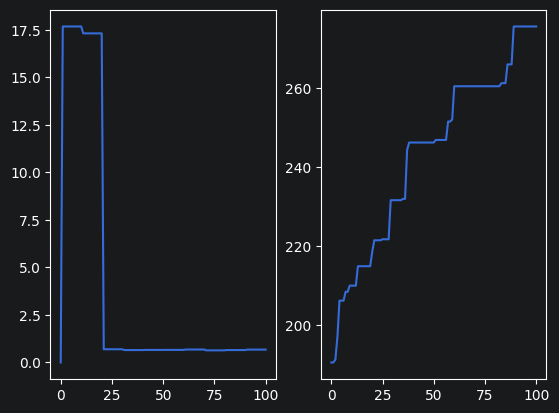

In [13]:
#@title Visualization


%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plots and the grid
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False)
sns.lineplot(x=metrics["iteration"], y=metrics["time"], ax=ax1)
sns.lineplot(x=metrics["iteration"], y=metrics["max_fitness"], ax=ax2)
plt.show()

In [14]:
#@title Best individual
best_idx = jnp.argmax(repertoire.fitnesses)
best_fitness = jnp.max(repertoire.fitnesses)
print(
    f"Best fitness in the repertoire: {best_fitness:.2f}\n",
    f"Index in the repertoire of this individual: {best_idx}\n"
)
my_params = jax.tree.map(
    lambda x: x[best_idx],
    repertoire.genotypes
)

Best fitness in the repertoire: 275.69
 Index in the repertoire of this individual: 0



Play some steps in the environment

In [15]:
jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(gp_policy_structure.apply)

In [16]:
rollout = []
key, subkey = jax.random.split(key)
state = jit_env_reset(rng=subkey)
list_pipeline_states = []
cumulative_reward = 0
while not state.done:
    rollout.append(state)
    action = jit_inference_fn(my_params, state.obs)
    state = jit_env_step(state, action)
    cumulative_reward += state.reward
    list_pipeline_states.append(state.pipeline_state)

print(f"The trajectory of this individual contains {len(rollout)} transitions, fitness is {cumulative_reward}.")

The trajectory of this individual contains 100 transitions, fitness is 267.4439697265625.


In [17]:
def save_rollout_html(env, pipeline_env_list, file_name: str):
    sys = env.sys.tree_replace({'opt.timestep': env.dt})
    rollout_html = html.render(sys, pipeline_env_list)
    with open(file_name, 'w') as f:
        f.write(rollout_html)


save_rollout_html(env, list_pipeline_states, "rollout.html")